# Elife Paper 
## Figure 6L: Neural Activity


In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import json
import pickle
# import queue
from scipy.integrate import solve_ivp
from dual_pathway_model.functions import *
from dual_pathway_model.directory_functions import *
from dual_pathway_model.model import NN, Environment, params_base
from dual_pathway_model.plotting_functions import *
from matplotlib.gridspec import GridSpec
from matplotlib import cm, colors
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import LinearSegmentedColormap

Base parameters loaded from params.yaml
Testing
Plotting colors safely loaded


In [2]:
# # load parameters from json file
# params_path = "params_6.json" # yeah we are using the old one again, its good shit
# # Open the file and read the contents
# with open(params_path, "r") as f:
#     parameters = json.load(f)

parameters = update_params(params_base,
                           **{
                               "params.N_SYLL": 20,
                            #    "params.RECORD_WEIGHTS": 0,
                            #    "params.BG_NOISE": 0.2,
                            #    "const.HVC_SIZE":20
                           } )
# running conditions
N_DAILY_MOTIFS = parameters['params']['TRIALS'] # trials per day per syllable  # old code TRIALS
TRIALS = N_DAILY_MOTIFS
BG_INTACT_DAYS = parameters['params']['BG_INTACT_DAYS']
DAYS = parameters['params']['DAYS'] # days for learning
N_SYLL = parameters['params']['N_SYLL'] # number of syllables   
if N_SYLL > 5 or N_SYLL < 1:
    ValueError('Invalid number of syllables')
RANDOM_SEED = 25495
ANNEALING = parameters['params']['ANNEALING'] # annealing 
print(ANNEALING)                  
print(f'Random seed is {RANDOM_SEED}')

1
Random seed is 25495


In [3]:
# Config
# 1 to load model
# 1 to save model
load = 0
save = 0
model_version = "model_20"  # e.g., "model","model_1" "model20", "model_4_40", "model_syrinx_4_41"etc.

model_path = f"{model_version}.pkl"

if load:
    if os.path.exists(model_path):
        with open(model_path, 'rb') as f:
            obj = pickle.load(f)
            print(f"Model '{model_version}' loaded successfully!")
    else:
        raise FileNotFoundError(f"Model file '{model_path}' not found.")

else:
    obj = Environment(RANDOM_SEED, parameters, NN)
    obj.run(parameters, ANNEALING)

    if save:
        if os.path.exists(model_path):
            print(f"Model file '{model_path}' already exists. Not overwriting.")
        else:
            try:
                pickle.dumps(obj)  # Test serialization
                with open(model_path, "wb") as f:
                    pickle.dump(obj, f)
                print(f"Model '{model_version}' saved successfully.")
            except pickle.PicklingError:
                print("Object cannot be pickled!")


  0%|          | 0/60 [00:00<?, ?it/s]

100%|██████████| 60/60 [03:00<00:00,  3.01s/it]


In [4]:
# # Poisson Spike Plotter
# def spike_plotter_poisson(rate_array, size_of_time_bin, scaling_factor = 1, rate_max=400, dt = 0.001, state=42):
#     time_bins, channels = rate_array.shape
#     # dt = 0.02 / time_points_per_rate  # 20ms per coarse bin, divided into fine bins
#     scaling_factor = rate_max * 0.02  # 0.02s = 20ms

#     spike_raster = np.zeros((time_bins * size_of_time_bin, channels), dtype=int)
#     np.random.seed(state)
#     for c in range(channels):
#         for t in range(time_bins):
#             start = t * size_of_time_bin
#             end = (t + 1) * size_of_time_bin
#             # Compute expected spike count (lambda) for this 20ms window
#             rate = squash(rate_array[t, c], p=20, a=0.00) * scaling_factor # rate from 0-1 to 0-8 spikes per timestep
#             # np.random.seed(state + c + 2*t + c*t) 
#             spike_count = np.random.poisson(rate* rate_max * dt) 
#             # print(spike_count, rate)

#             # Randomly assign spike_count spikes within the window
#             if spike_count > 0:
#                 spike_times = np.random.choice(size_of_time_bin, size=spike_count, replace=False)
#                 spike_raster[start + spike_times, c] = 1
#     return spike_raster


In [5]:
# import numpy as np

def poisson_eventplot_from_rates(
    rate_array,
    bin_size_ms,
    rate_max=NotImplementedError,
    rate_min=0,
    refractory_ms=1.0,
    seed=None,
    mode="bernoulli",
    return_rates=False
):
    ''' 
    Takes array from rates -1 to 1 and then maps them 
    to r_min to r_max rate of firing
    '''
    if seed is not None:
        np.random.seed(seed)

    # ensure numpy array
    rate_array = np.asarray(rate_array, dtype=float)

    time_bins, channels = rate_array.shape

    # time setup (seconds)
    DT = 1 / 1000.0  # 1 ms resolution
    bin_size_s = bin_size_ms / 1000.0
    tau_ref = refractory_ms / 1000.0
    steps_per_bin = int(bin_size_s / DT)
    print(f"Bin size: {bin_size_s}s, Steps per bin: {steps_per_bin}, Refractory period: {tau_ref}s")

    spike_times_all_channels = [[] for _ in range(channels)]

    for c in range(channels):
        last_spike_time = -np.inf

        for t in range(time_bins):
            # scale rate to Hz

            r = (rate_array[t, c] + 1) / 2 * (rate_max - rate_min) + rate_min
            if mode == "bernoulli":
                for k in range(steps_per_bin):
                    t_now = t * bin_size_s + k * DT + DT / 2 + 0.5*DT*np.random.rand() # center of the time step and small jitter to avoid perfect alignment
                    # refractory check
                    if t_now - last_spike_time < tau_ref:
                        # print(f"Time {t_now:.3f}s, Rate {r:.2f}Hz, Spike Prob skipped due to refractory period")
                        continue
                    # map rate -1 to 1 to 0 to 1 and then probability of spiking
                    p = r * DT # rate from 0-1 to 0-1 probability per time step
                    # print(f"Time {t_now:.3f}s, Rate {r:.2f}Hz, Spike Prob {p:.4f}")
                    if p > 1.0:
                        p = 1.0
                    if np.random.rand() < p:
                        spike_times_all_channels[c].append(t_now)
                        last_spike_time = t_now

            elif mode == "fake-poisson":
                # correct version at bin level
                lam = r * bin_size_s  # expected spikes per bin
                k_spikes = np.random.poisson(lam)

                if k_spikes > 0:
                    spikes = t * bin_size_s + np.random.uniform(0, bin_size_s, size=k_spikes)
                    spikes.sort()

                    for s in spikes:
                        if s - last_spike_time >= tau_ref:
                            spike_times_all_channels[c].append(s)
                            last_spike_time = s

    # reverse for plotting (optional)
    spike_times_all_channels = spike_times_all_channels[::-1]

    total_time = time_bins * bin_size_s
    time = np.linspace(0, total_time, int(total_time / DT) + 1)

    # firing rate check - convert spike times back to rates for verification
    if return_rates:
        reconstructed_rates = np.zeros_like(rate_array)
        for c in range(channels):
            spike_times = np.array(spike_times_all_channels[c])
            for t in range(time_bins):
                start = t * bin_size_s
                end = (t + 1) * bin_size_s
                count = np.sum((spike_times >= start) & (spike_times < end))
                reconstructed_rates[t, c] = count / bin_size_s  # convert back to rate
        return spike_times_all_channels, time, reconstructed_rates

    return spike_times_all_channels, time

In [6]:
def poisson_eventplot_from_rates_v2(
    rate_array,
    bin_size_ms=10,
    threshold_max=0.6,
    seed=None,
):
    threshold_max /= 1000
    if seed is not None:
        np.random.seed(seed)

    rate_array = np.asarray(rate_array, dtype=float)
    time_bins, channels = rate_array.shape

    steps_per_bin = int(bin_size_ms)       # 1 step = 1 ms
    bin_size_s = bin_size_ms / 1000.0

    spike_times_all_channels = [[] for _ in range(channels)]

    for c in range(channels):
        skip_next = False
        for t in range(time_bins):
            threshold = (rate_array[t, c] + 1) / 2.0 * threshold_max
            for k in range(steps_per_bin):
                if skip_next:
                    skip_next = False
                    continue
                if np.random.rand() < threshold:
                    t_now = (t * bin_size_ms + k) / 1000.0
                    spike_times_all_channels[c].append(t_now)
                    skip_next = True

    # reverse so channel 0 plots at top
    spike_times_all_channels = spike_times_all_channels[::-1]

    total_time = time_bins * bin_size_s
    time = np.linspace(0, total_time, int(total_time * 1000) + 1)

    return spike_times_all_channels, time

In [7]:
# # array from -1 to 1
# array = np.array([
#     [-1,-0.8,-0.6,-0.4,-0.2,0,0.2,0.4,0.6],
#     [-0.8,-0.6,-0.4,-0.2,0,0.2,0.4,0.6,0.8],
#     [-0.6,-0.4,-0.2,0,0.2,0.4,0.6,0.8,1]
# ], dtype=float)

# array/=np.max(array)
# print(array)
# plt.imshow(array, cmap='viridis')
# plt.colorbar()
# plt.show()

# spikes, time, reconstructed_rates = poisson_eventplot_from_rates(array, bin_size_ms=10, rate_max=1000, refractory_ms=1, return_rates=True)

# plt.figure(figsize=(6, 3))
# plt.eventplot(
#     spikes,
#     orientation="horizontal",
#     lineoffsets=np.arange(len(spikes)),
#     linelengths=0.8,
# )
# # plt.xlim(0, time[-1])
# # plt.yticks(np.arange(len(spikes)), labels=[f"ch {i}" for i in range(len(spikes))])
# plt.xlabel("Time (s)")
# plt.ylabel("Channel")
# plt.show()

# plt.imshow(reconstructed_rates, aspect='auto', cmap='viridis')
# plt.colorbar(label='Firing Rate (Hz)')
# plt.show()

### A: HVC Neurons

In [8]:
rate_fig_size = (15,15*.37)
raster_fig_size = (15*.91,15*.37)
xlabel_size = 45
ylabel_size = 45
tick_label_size = 35
cbar_label_size = 35
cbar_tick_label_size = 25

HVC array shape: (60, 1000, 20, 100)
Figure saved as  Plots\Figure_6a1.pdf
-1.0 1.0
-1.0 1.0
Figure saved as  Plots\Figure_6a2.pdf
Figure saved as  Plots\Figure_6a3.pdf
-1.0 1.0
-1.0 1.0
Figure saved as  Plots\Figure_6a4.pdf


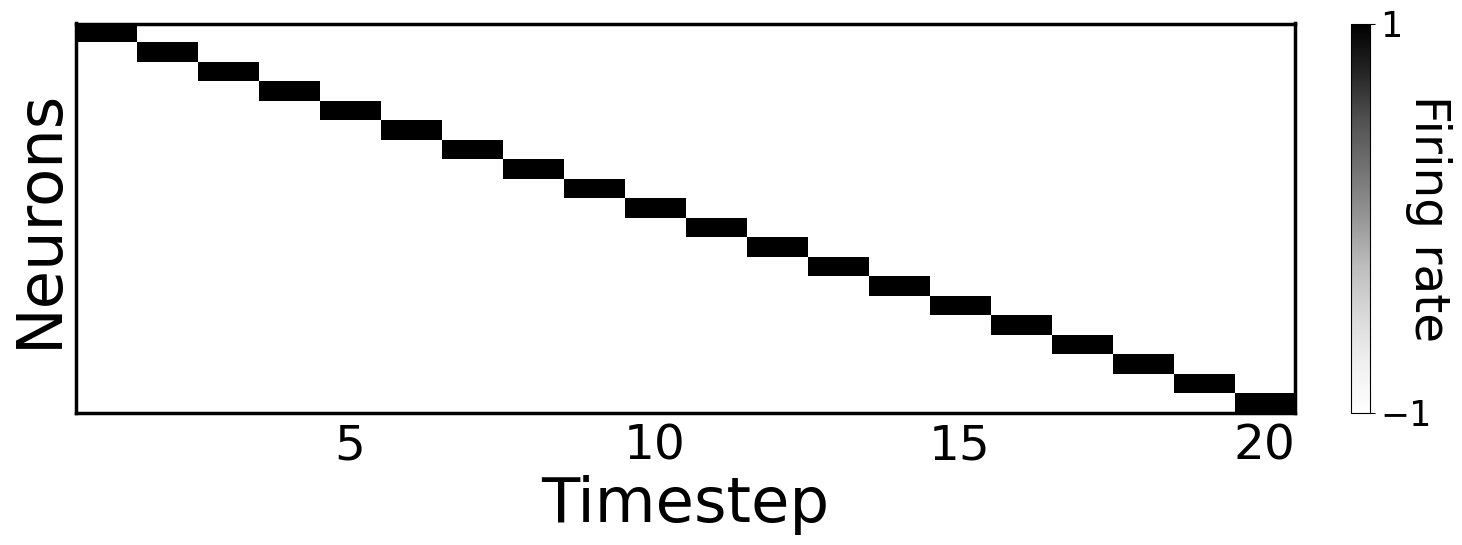

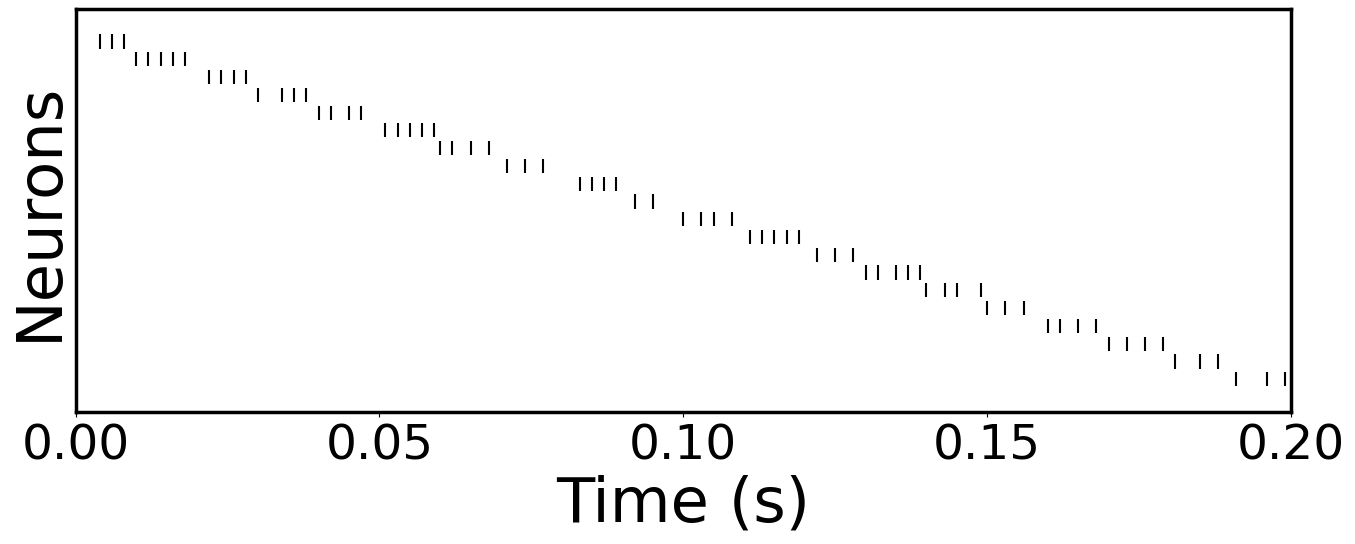

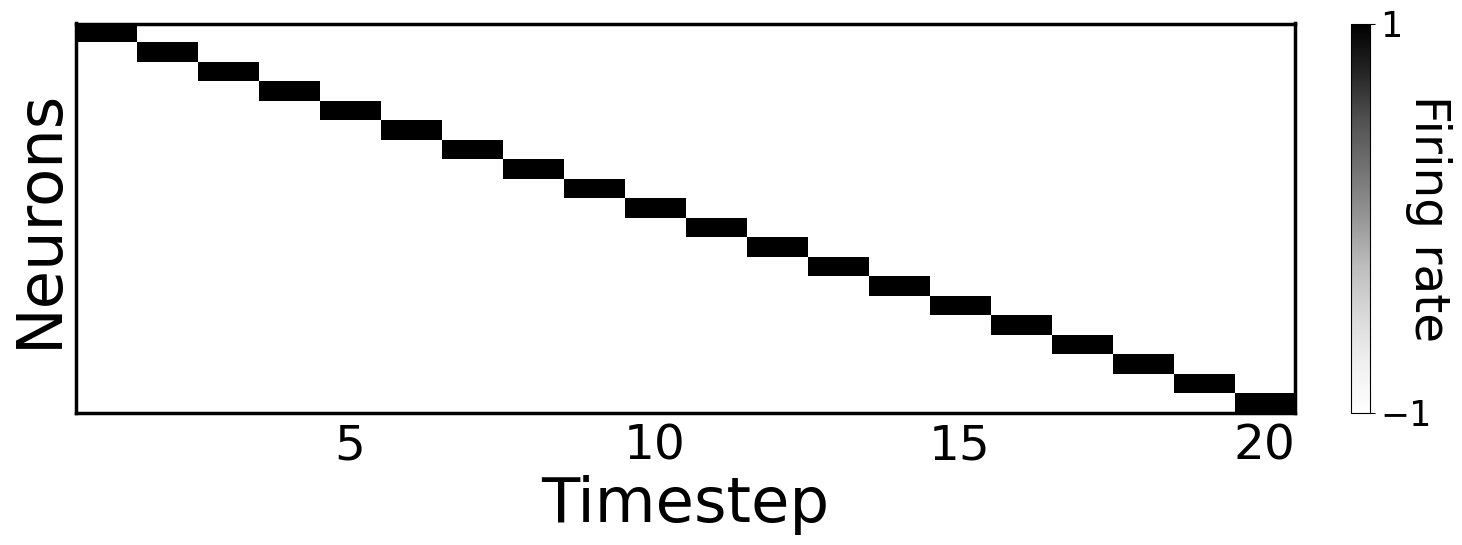

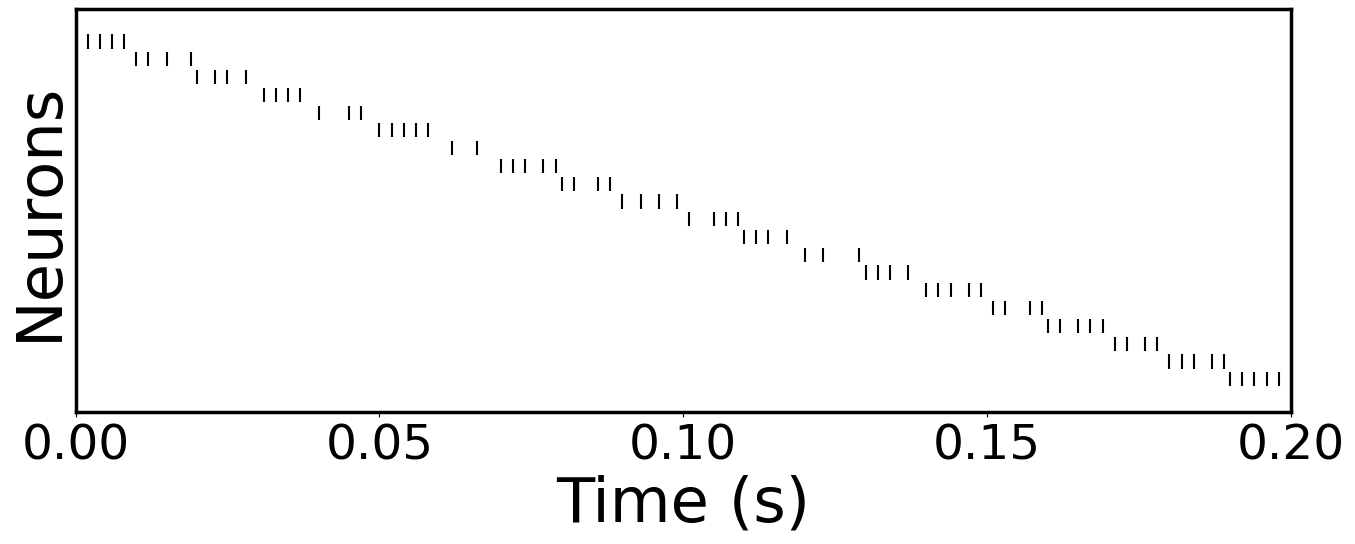

In [9]:
hvc_neurons = 100
hvc_array_all = np.zeros((DAYS, TRIALS, N_SYLL, hvc_neurons))

# Create one-hot vector for each syllable
one_hot = np.eye(hvc_neurons)[np.arange(N_SYLL)]  # shape: (N_SYLL, hvc_neurons)

# Broadcast across days and trials
hvc_array_all[:, :, :, :] = one_hot[np.newaxis, np.newaxis, :, :]

# map from 0 to 1 to -1 to 1
hvc_array_all = hvc_array_all * 2 - 1

print("HVC array shape:", hvc_array_all.shape)  # Should be (DAYS, TRIALS, N_SYLL, hvc_neurons)

def plot_HVC_motifs_days_rate(day):
    """ Plots the model output over time. """
    figure, (ax1) = plt.subplots(1, figsize=rate_fig_size)
    nos_trials_per_day = 1
    nos_neurons = 20
    plot_array = hvc_array_all[day, :nos_trials_per_day,:,:nos_neurons].reshape(nos_trials_per_day*nos_neurons, N_SYLL, order = 'F').T
    im1 = ax1.imshow(plot_array.T, aspect='auto', cmap='Greys', interpolation='nearest', vmin = -1, vmax = 1)   
    cbar = figure.colorbar(im1, ax=ax1, fraction=0.092, pad=0.04)
    cbar.set_label('Firing rate', fontsize=cbar_label_size, rotation=270, labelpad=15)
    cbar.set_ticks([-1, 1])
    cbar.ax.tick_params(labelsize=cbar_tick_label_size)
    ax1.set_xticks(np.arange(4,20,5), np.arange(5,21,5))
    ax1.tick_params(axis='x', which='both', bottom=False)
    ax1.tick_params(labelsize=tick_label_size)
    # ax1.set_title(f'DPH {day+40}', fontsize=35)
    ax1.set_yticks([])
    ax1.set_ylabel('Neurons', fontsize=ylabel_size)    
    ax1.set_xlabel('Timestep', fontsize=xlabel_size)
    for spine in ax1.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color('black')
    plt.tight_layout()
    # plt.show()

def plot_HVC_motifs_on_day_spike(day, seed=None, rate_max=0, rate_min=0):
    """ Plots the model output over time. """
    figure, (ax1) = plt.subplots(1, figsize=raster_fig_size)
    nos_trials_per_day = 1
    nos_neurons = 20
    print(np.min(hvc_array_all), np.max(hvc_array_all))
    plot_array = hvc_array_all[day, :nos_trials_per_day,:,:nos_neurons].reshape(nos_trials_per_day*nos_neurons, N_SYLL, order = 'F').T
    spikes, time = poisson_eventplot_from_rates_v2(plot_array, bin_size_ms=10, threshold_max=rate_max, seed=seed)
    print(np.min(plot_array), np.max(plot_array))
    plt.eventplot(
        spikes,
        orientation="horizontal",
        lineoffsets=np.arange(len(spikes)),
        linelengths=0.8,
        colors='black',)
    ax1.set_xlim(0, 0.01*N_SYLL)
    ax1.set_yticks([])
    ax1.set_xticks([0,0.05,0.1,0.15,0.2])
    ax1.tick_params(labelsize=tick_label_size)
    ax1.set_ylabel('Neurons', fontsize=ylabel_size)    
    ax1.set_xlabel('Time (s)', fontsize=xlabel_size)
    for spine in ax1.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color('black')
    plt.tight_layout()

    # plt.show()

plot_HVC_motifs_days_rate(day=0)
save_figure('Figure_6a1', save=True, dpi=300)
plot_HVC_motifs_on_day_spike(day=0, seed=42, rate_max=400/0.6, rate_min=0)
save_figure('Figure_6a2', save=True, dpi=300)
plot_HVC_motifs_days_rate(day=59)
save_figure('Figure_6a3', save=True, dpi=300)
plot_HVC_motifs_on_day_spike(day=59, seed=43, rate_max=400/0.6, rate_min=0)
save_figure('Figure_6a4', save=True, dpi=300)

### B: RA neurons

<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
C:\Users\rsankar\AppData\Local\Temp\ipykernel_5796\3286725270.py:13: SyntaxWarning: invalid escape sequence '\p'
  print(f"Mean var of all neurons: {np.mean(np.std(plot_array, axis = 1)):.3f} $\pm${np.std(np.std(plot_array, axis = 1)):.3f}")


18
Variability of a single neuron 0.006454953016652964
Mean var of all neurons: 0.357 $\pm$0.285
Stdev of variability of all neurons: 0.28540408167506576
Figure saved as  Plots\Figure_6b1.pdf
Variability of a single neuron 0.009026296298455637
Mean var of all neurons: 0.056 $\pm$0.129
Stdev of variability of all neurons: 0.1290322779830649
Figure saved as  Plots\Figure_6b3.pdf
Figure saved as  Plots\Figure_6b2.pdf
Figure saved as  Plots\Figure_6b4.pdf


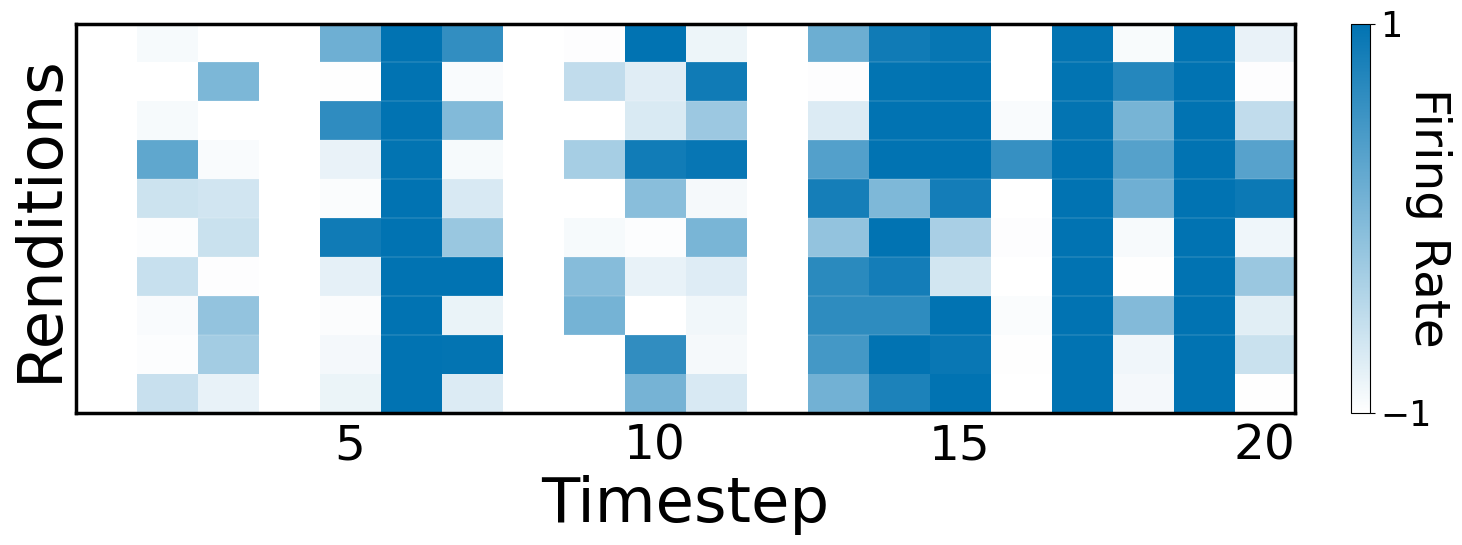

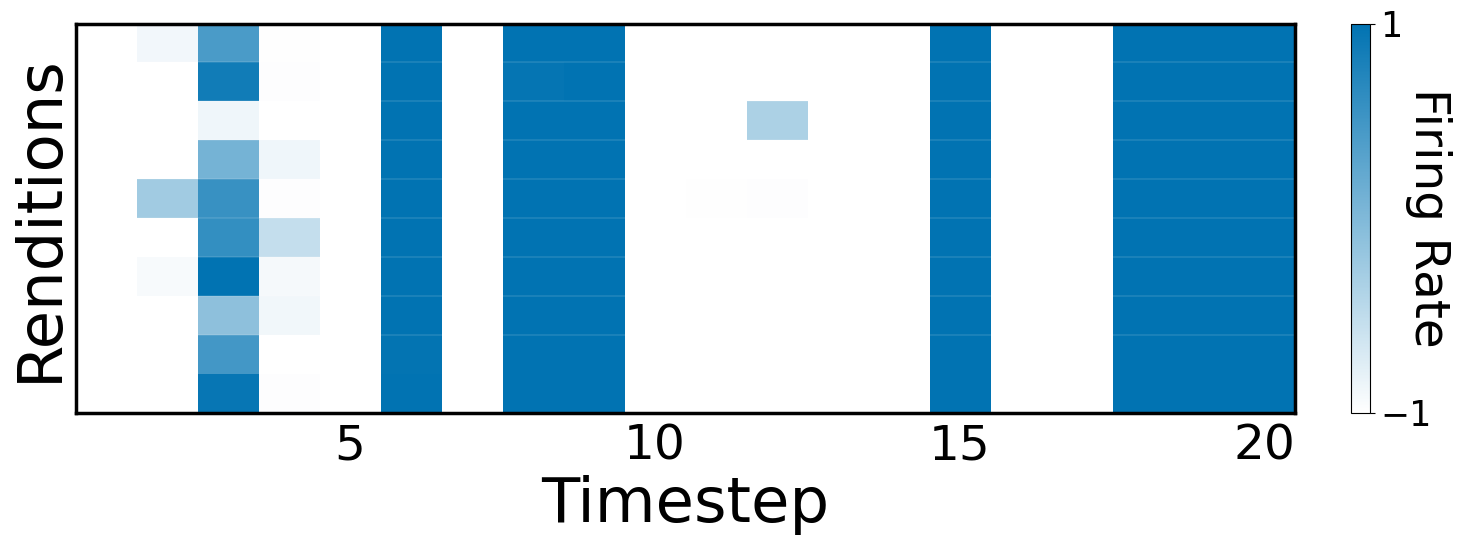

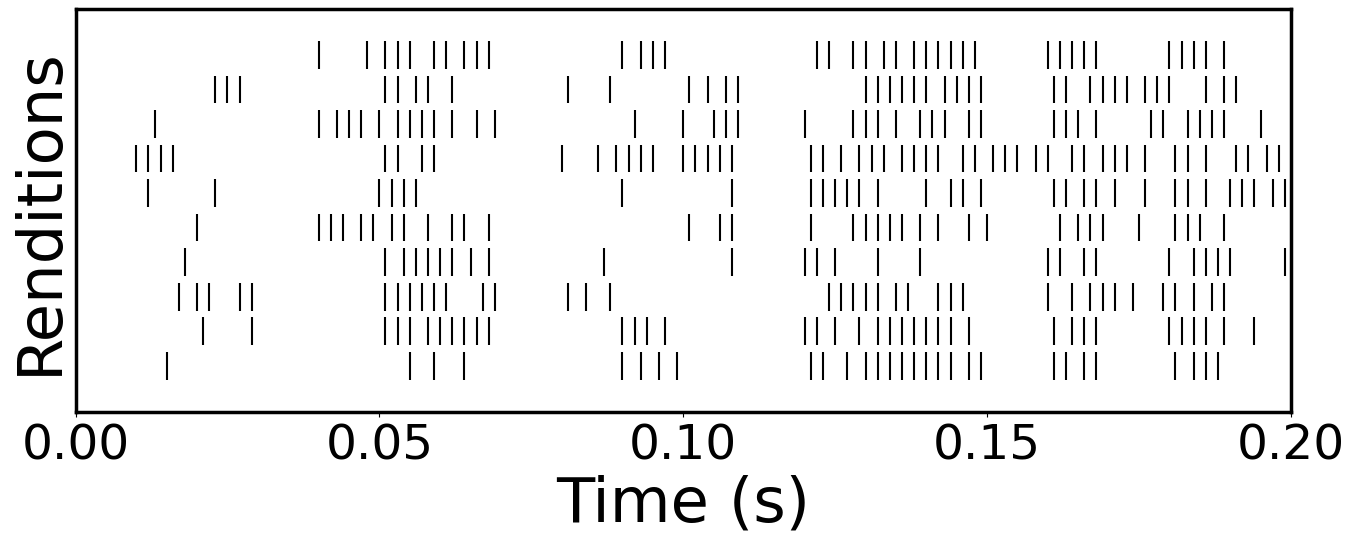

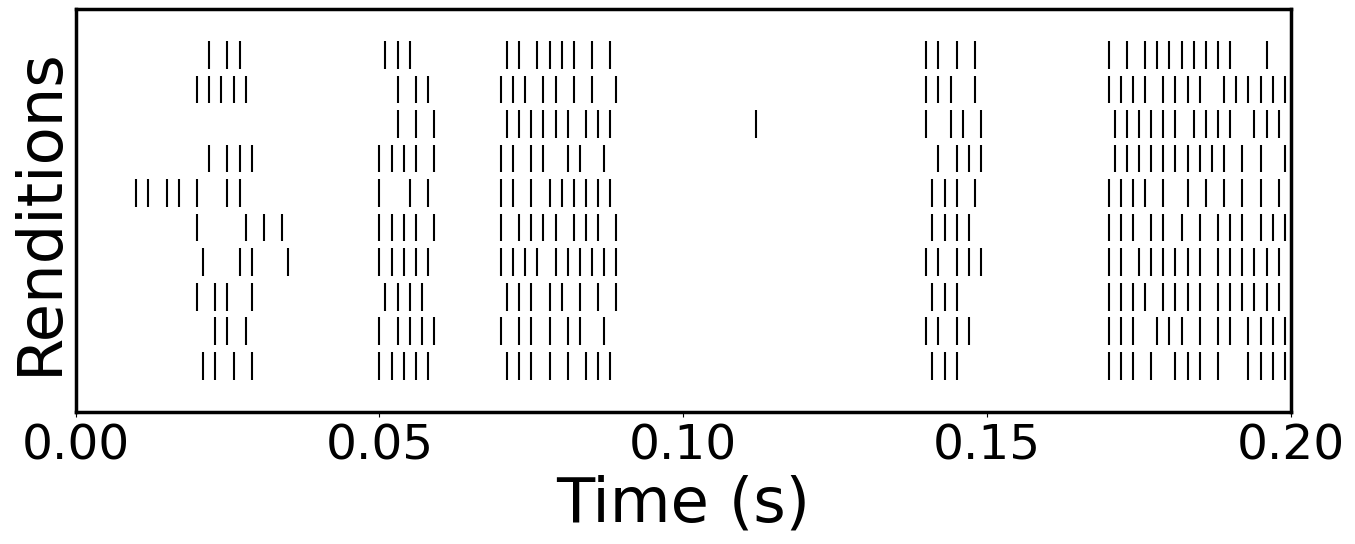

In [10]:
nk = 18
# nk+=1
print(nk)
def plot_HL_motifs_days_rate(obj, day):
    """ Plots the model output over time. """
    figure, (ax1) = plt.subplots(1, figsize=rate_fig_size)
    cm = LinearSegmentedColormap.from_list('white_to_black', ['white', color_cortical])
    nos_trials_per_day = 10
    neuron_numbers = [nk]
    nos_neurons = len(neuron_numbers)
    plot_array = obj.ra_all[day, :nos_trials_per_day, :, neuron_numbers].reshape(nos_trials_per_day*nos_neurons, N_SYLL, order = 'F').T
    print("Variability of a single neuron", np.std(plot_array[5,:]))
    print(f"Mean var of all neurons: {np.mean(np.std(plot_array, axis = 1)):.3f} $\pm${np.std(np.std(plot_array, axis = 1)):.3f}")
    print("Stdev of variability of all neurons:", np.std(np.std(plot_array, axis = 1)))
    im1 = ax1.imshow(plot_array.T, aspect='auto', cmap=cm, interpolation='nearest', vmin = -1, vmax = 1)   
    cbar = figure.colorbar(im1, ax=ax1, fraction=0.092, pad=0.04)
    cbar.set_label('Firing Rate', fontsize=cbar_label_size, rotation=270, labelpad=15)
    cbar.set_ticks([-1, 1])
    cbar.ax.tick_params(labelsize=cbar_tick_label_size)
    ax1.hlines(y = np.arange(nos_neurons*8+1)-0.5, xmin = -0.5, xmax = N_SYLL*1-0.5, color='white', alpha = 0.1)
    ax1.hlines(y = np.arange(0,nos_neurons*8,8)-0.5, xmin = -0.5, xmax = N_SYLL*1-0.5, color='white', lw=1)
    ax1.set_xticks(np.arange(4,20,5), np.arange(5,21,5))
    ax1.tick_params(axis='x', which='both', bottom=False)
    ax1.tick_params(labelsize=tick_label_size)
    # ax1.set_title(f'DPH {day+40}', fontsize=35)
    ax1.set_yticks([])
    ax1.set_ylabel('Renditions', fontsize=ylabel_size)    
    ax1.set_xlabel('Timestep', fontsize=xlabel_size)
    for spine in ax1.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color('black')
    plt.tight_layout()
    # plt.show()

def plot_HL_motifs_on_day_spike(obj, day, threshold_max=0.6, seed=None):
    """ Plots the model output over time as a spike raster using poisson_eventplot_from_rates_v2. """
    figure, (ax1) = plt.subplots(1, figsize=raster_fig_size)
    nos_trials_per_day = 10
    neuron_numbers = [nk]

    nos_neurons = len(neuron_numbers)
    plot_array = obj.ra_all[day, :nos_trials_per_day, :, neuron_numbers].reshape(nos_trials_per_day*nos_neurons, N_SYLL, order = 'F').T

    spikes, time = poisson_eventplot_from_rates_v2(plot_array, bin_size_ms=10, threshold_max=threshold_max, seed=seed)

    ax1.eventplot(
        spikes,
        orientation="horizontal",
        lineoffsets=np.arange(len(spikes)),
        linelengths=0.8,
        colors='black',)
    ax1.set_xlim(0, 0.01*N_SYLL)
    ax1.set_yticks([])
    ax1.set_xticks([0, 0.05, 0.1, 0.15, 0.2])
    ax1.tick_params(labelsize=tick_label_size)
    ax1.set_ylabel('Renditions', fontsize=ylabel_size)    
    ax1.set_xlabel('Time (s)', fontsize=xlabel_size)
    for spine in ax1.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color('black')
    plt.tight_layout()
    # plt.show()

plot_HL_motifs_days_rate(obj,0)
save_figure('Figure_6b1', save=True, dpi=300)
plot_HL_motifs_days_rate(obj, 59) 
save_figure('Figure_6b3', save=True, dpi=300)
plot_HL_motifs_on_day_spike(obj, 0, threshold_max=400/0.6)
save_figure('Figure_6b2', save=True, dpi=300)
plot_HL_motifs_on_day_spike(obj, 59, threshold_max=400/0.6)
save_figure('Figure_6b4', save=True, dpi=300)

### C: BG neurons

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
C:\Users\rsankar\AppData\Local\Temp\ipykernel_5796\994067445.py:17: SyntaxWarning: invalid escape sequence '\p'
  print(f"Mean var of all neurons: {np.mean(np.std(plot_array, axis = 1)):.3f} $\pm${np.std(np.std(plot_array, axis = 1)):.3f}")


nk: 37
Variability of a single neuron 0.27577633830521375
Mean var of all neurons: 0.188 $\pm$0.086
Stdev of variability of all neurons: 0.08624526855186362
Figure saved as  Plots\Figure_6c1.pdf
Variability of a single neuron 0.19011354262407804
Mean var of all neurons: 0.168 $\pm$0.048
Stdev of variability of all neurons: 0.04806076253793161
Figure saved as  Plots\Figure_6c3.pdf
Figure saved as  Plots\Figure_6c2.pdf
Figure saved as  Plots\Figure_6c4.pdf


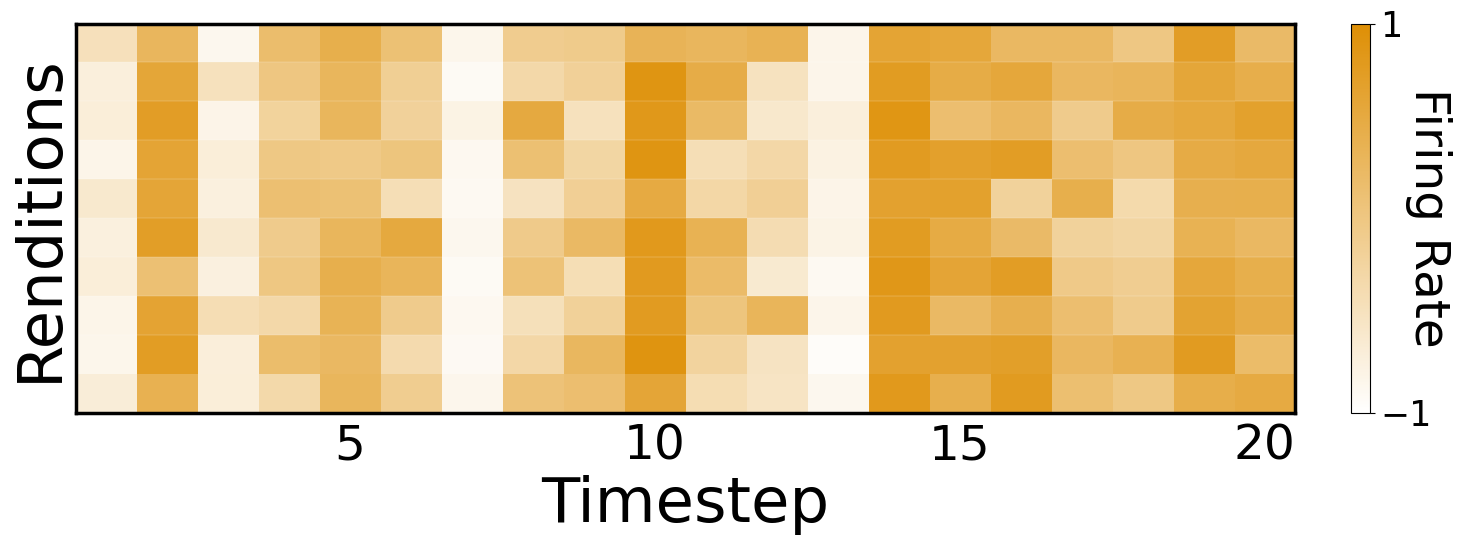

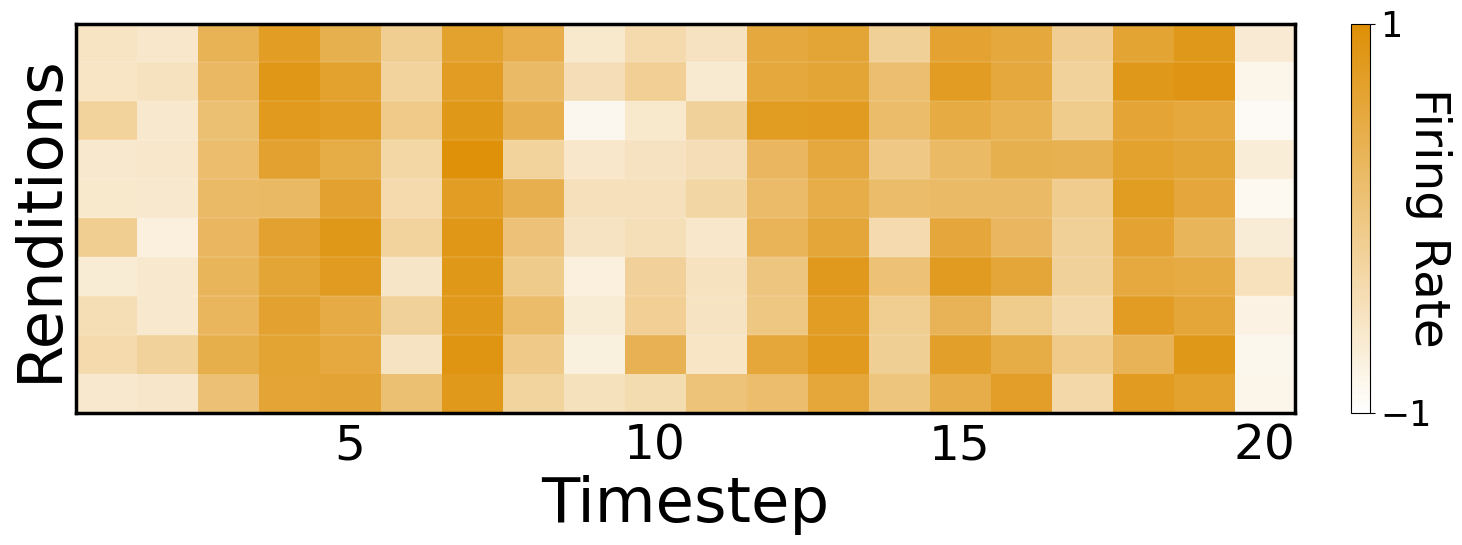

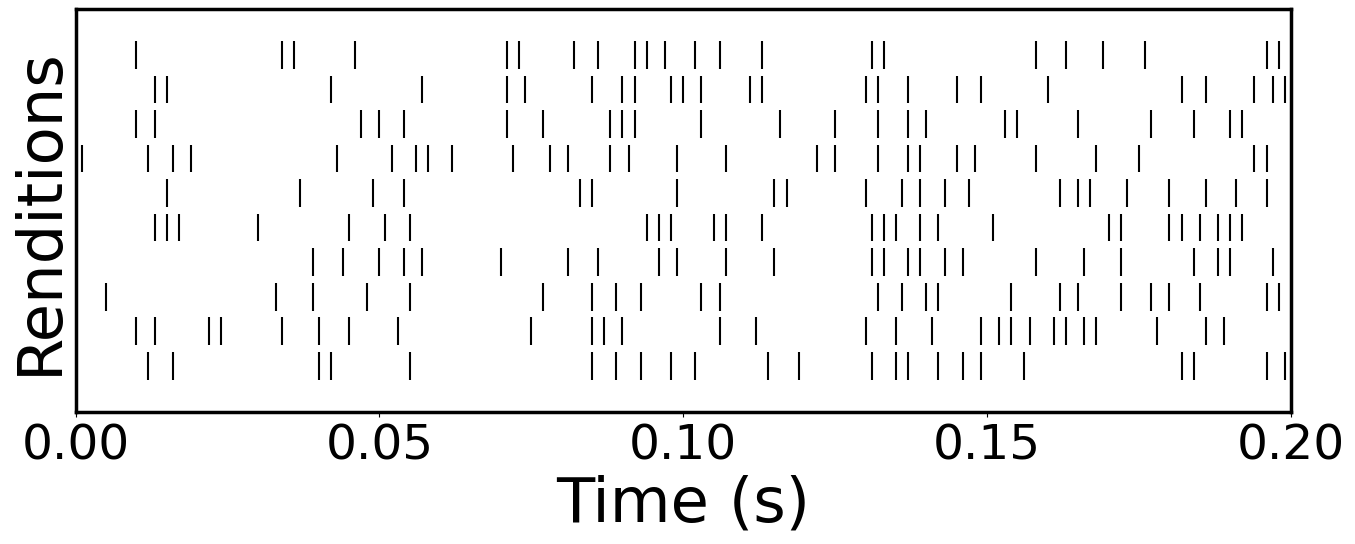

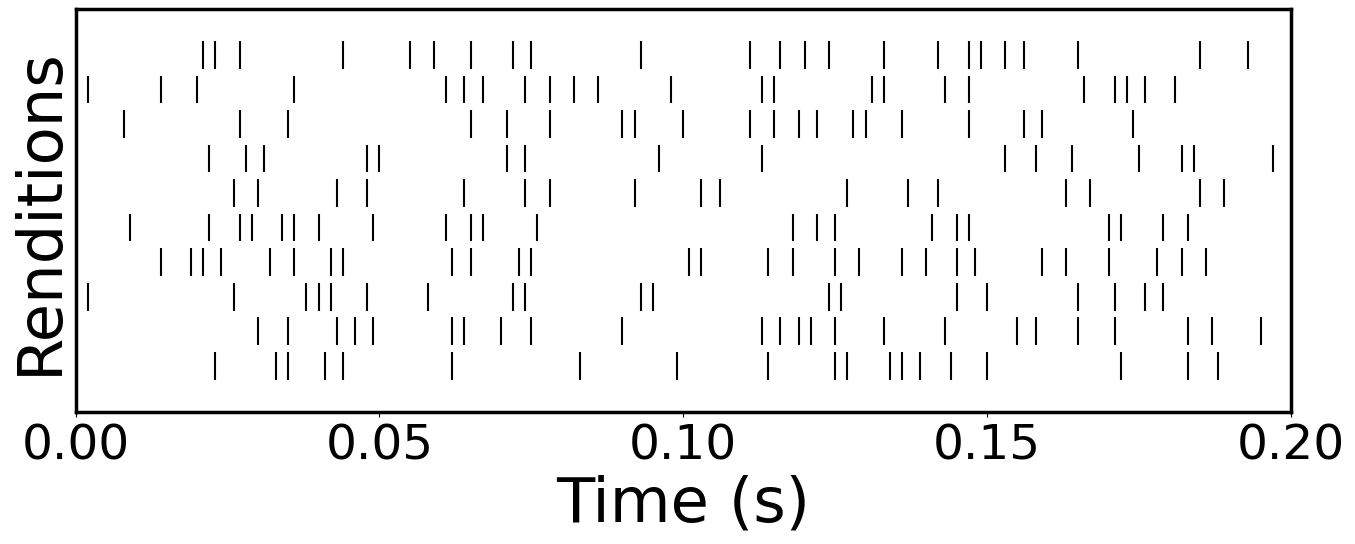

In [11]:
nk = 37
# nk+=1

def plot_RL_motifs_days_rate(obj, day):
    """ Plots the BG model output over time (rate heatmap). """
    figure, ax1 = plt.subplots(1, figsize=rate_fig_size)


    cm = colors.LinearSegmentedColormap.from_list('my_cmap', ['white', color_bg], N=256)
    nos_trials_per_day = 10
    neuron_numbers = [nk]
    nos_neurons = len(neuron_numbers)

    plot_array = obj.bg_all[day, :nos_trials_per_day, :, neuron_numbers] \
                    .reshape(nos_trials_per_day*nos_neurons, N_SYLL, order='F').T
    print("Variability of a single neuron", np.std(plot_array[5,:]))
    print(f"Mean var of all neurons: {np.mean(np.std(plot_array, axis = 1)):.3f} $\pm${np.std(np.std(plot_array, axis = 1)):.3f}")
    print("Stdev of variability of all neurons:", np.std(np.std(plot_array, axis = 1)))
    im1 = ax1.imshow(plot_array.T, aspect='auto', cmap=cm,
                     interpolation='nearest', vmin=-1, vmax=1)

    cbar = figure.colorbar(im1, ax=ax1, fraction=0.092, pad=0.04)
    cbar.set_label('Firing Rate', fontsize=cbar_label_size, rotation=270, labelpad=15)
    cbar.set_ticks([-1, 1])
    cbar.ax.tick_params(labelsize=cbar_tick_label_size)

    ax1.hlines(y=np.arange(nos_neurons*8+1)-0.5, xmin=-0.5, xmax=N_SYLL*1-0.5,
               color='white', alpha=0.1)
    ax1.hlines(y=np.arange(0, nos_neurons*8, 8)-0.5, xmin=-0.5, xmax=N_SYLL*1-0.5,
               color='white', lw=1)

    ax1.set_xticks(np.arange(4, 20, 5), np.arange(5, 21, 5))
    ax1.tick_params(axis='x', which='both', bottom=False)
    ax1.tick_params(labelsize=tick_label_size)
    # ax1.set_title(f'DPH {day+40}', fontsize=35)
    ax1.set_yticks([])
    ax1.set_ylabel('Renditions', fontsize=ylabel_size)
    ax1.set_xlabel('Timestep', fontsize=xlabel_size)
    for spine in ax1.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color('black')

    plt.tight_layout()
    # plt.show()


def plot_RL_motifs_on_day_spike(obj, day, rate_max=400/0.6, rate_min=0, seed=None):
    """ Plots the BG model output over time (spike raster). """
    figure, ax1 = plt.subplots(1, figsize=raster_fig_size)

    nos_trials_per_day = 10
    neuron_numbers = [nk]
    nos_neurons = len(neuron_numbers)
    plot_array = obj.bg_all[day, :nos_trials_per_day, :, neuron_numbers] \
                    .reshape(nos_trials_per_day*nos_neurons, N_SYLL, order='F').T

    spikes, time = poisson_eventplot_from_rates_v2(plot_array, bin_size_ms=10, threshold_max=rate_max, seed=seed)
    ax1.eventplot(
        spikes,
        orientation="horizontal",
        lineoffsets=np.arange(len(spikes)),
        linelengths=0.8,
        colors='black',)

    ax1.set_xlim(0, 0.01*N_SYLL)
    ax1.set_yticks([])
    ax1.set_xticks([0, 0.05, 0.1, 0.15, 0.2])
    ax1.tick_params(labelsize=tick_label_size)
    ax1.set_ylabel('Renditions', fontsize=ylabel_size)
    ax1.set_xlabel('Time (s)', fontsize=xlabel_size)
    for spine in ax1.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color('black')

    plt.tight_layout()
    # plt.show()

print("nk:", nk)

plot_RL_motifs_days_rate(obj, 0)
save_figure('Figure_6c1', save=True, dpi=300)
plot_RL_motifs_days_rate(obj, 59)
save_figure('Figure_6c3', save=True, dpi=300)

plot_RL_motifs_on_day_spike(obj, 0, rate_max=200/0.8, rate_min=0)
save_figure('Figure_6c2', save=True, dpi=300)
plot_RL_motifs_on_day_spike(obj, 59, rate_max=200/0.8, rate_min=0)
save_figure('Figure_6c4', save=True, dpi=300)

In [12]:
raise ValueError("Stop here for now")

ValueError: Stop here for now

In [ ]:
obj.ra_all.shape

(60, 1000, 20, 100)